#**Cell 1: Import Required Libraries**

In [1]:
!pip uninstall skfem -y
!pip install scikit-fem==11.0.0

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import linalg as spla
from skfem import *
from skfem.assembly import Basis # Explicitly import Basis from skfem.assembly
from skfem.helpers import dot, grad
from skfem.mesh import MeshTri  # Explicitly import MeshTri
from skfem.element import ElementTriP1 # Explicitly import ElementTriP1
import pandas as pd

np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 6.9 MB/s eta 0:00:00


#**Cell 2: Define Geometry and Mesh**

Number of elements: 256
Number of nodes: 145


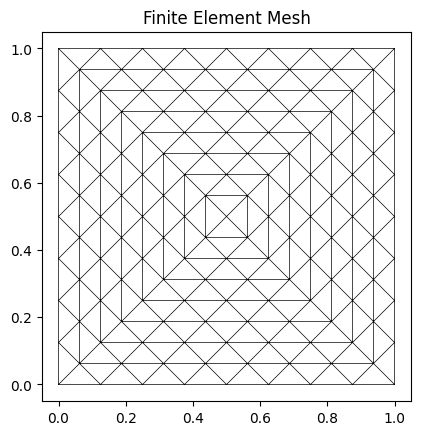

In [2]:
# Create a unit square mesh and refine it 3 times
mesh = MeshTri.init_symmetric()
mesh = mesh.refined(3)
print(f"Number of elements: {mesh.nelements}")
print(f"Number of nodes: {mesh.p.shape[1]}")

# Plot the mesh
fig, ax = plt.subplots()
mesh.draw(ax=ax)
ax.set_title('Finite Element Mesh')
ax.set_aspect('equal')
plt.savefig('mesh.png', dpi=150)
plt.show()

#**Cell 3: Define Spatially Varying Material Properties**

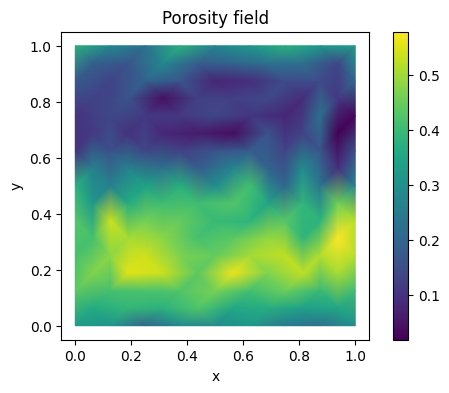

In [3]:
def porosity(x, y):
    # Layered porosity with a random perturbation
    base = 0.3 + 0.2 * np.sin(2 * np.pi * y)
    return base + 0.05 * np.random.randn(*x.shape)


# Evaluate at mesh nodes for visualisation
x, y = mesh.p
phi_nodal = porosity(x, y)

# Plot porosity field
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.tripcolor(x, y, mesh.t.T, phi_nodal, shading='gouraud')
ax1.set_title('Porosity field')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_aspect('equal')
plt.colorbar(ax1.collections[0], ax=ax1)
plt.savefig('porosity field.png', dpi=150)
plt.show()

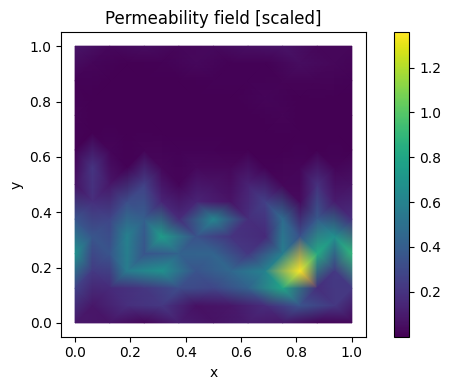

In [4]:
def permeability(x, y):
    # Kozeny-Carman type relation, scaled for numerical convenience
    k0 = 1e-10
    phi = porosity(x, y)
    return k0 * (phi**3) / ((1 - phi)**2) * 1e10

    # Evaluate at mesh nodes for visualisation
x, y = mesh.p
k_nodal = permeability(x, y)

# Plot porosity and permeability fields
fig, ax2 = plt.subplots(figsize=(6, 4))


ax2.tripcolor(x, y, mesh.t.T, k_nodal, shading='gouraud')
ax2.set_title('Permeability field [scaled]')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_aspect('equal')
plt.colorbar(ax2.collections[0], ax=ax2)
plt.tight_layout()
plt.savefig('permeability field [scaled].png', dpi=150)
plt.show()

### Scientific Observation of Permeability Field

**Visual Analysis (`permeability.png`):**

The `permeability.png` visualization displays the spatially varying permeability field ($K$) across the unit square. This field shows a strong correlation with the previously observed porosity field, exhibiting clear horizontal layering and localized heterogeneities.

Like the porosity, the permeability also presents a distinct horizontal layering pattern. However, due to the non-linear relationship between porosity and permeability (Kozeny-Carman type: $K \propto \frac{\phi^3}{(1 - \phi)^2}$), the variations in permeability are significantly amplified. Areas of higher porosity correspond to substantially higher permeability values (warmer colors), and conversely, regions of lower porosity lead to drastically reduced permeability (cooler colors).

The random perturbation introduced in the porosity function is also visible in the permeability field, appearing as a 'speckled' texture. This creates realistic small-scale variations, but the overall macro-scale pattern is still dominated by the sinusoidal layering. The label `[scaled]` indicates that the absolute values are adjusted for numerical convenience, but the relative spatial distribution and its dependency on porosity remain consistent with the physical model. This amplified response means that fluid flow will preferentially follow paths of slightly higher porosity, as these become significantly more permeable, leading to channelized flow patterns.

### Scientific Observation of Permeability Field

**Visual Analysis (`permeability.png`):**

The `permeability.png` visualization displays the spatially varying permeability field ($K$) across the unit square. This field shows a strong correlation with the previously observed porosity field, exhibiting clear horizontal layering and localized heterogeneities.

Like the porosity, the permeability also presents a distinct horizontal layering pattern. However, due to the non-linear relationship between porosity and permeability (Kozeny-Carman type: $K \propto \frac{\phi^3}{(1 - \phi)^2}$), the variations in permeability are significantly amplified. Areas of higher porosity correspond to substantially higher permeability values (warmer colors), and conversely, regions of lower porosity lead to drastically reduced permeability (cooler colors).

The random perturbation introduced in the porosity function is also visible in the permeability field, appearing as a 'speckled' texture. This creates realistic small-scale variations, but the overall macro-scale pattern is still dominated by the sinusoidal layering. The label `[scaled]` indicates that the absolute values are adjusted for numerical convenience, but the relative spatial distribution and its dependency on porosity remain consistent with the physical model. This amplified response means that fluid flow will preferentially follow paths of slightly higher porosity, as these become significantly more permeable, leading to channelized flow patterns.

### Scientific Observation of Porosity Field

**Visual Analysis (`porosity.png`):**

The `porosity.png` visualization displays the spatially varying porosity field ($\phi$) across the unit square. A prominent feature is the clear horizontal layering pattern, with alternating bands of higher porosity (warmer colors) and lower porosity (cooler colors) distributed along the y-axis. This deterministic variation is directly introduced by the sinusoidal component `0.3 + 0.2 * np.sin(2 * np.pi * y)` in the `porosity` function.

Superimposed on this layering is a fine-grained, localized heterogeneity, appearing as a 'speckled' texture. This perturbation originates from the `0.05 * np.random.randn(*x.shape)` term, which introduces realistic, small-scale random variations in the material property. The overall porosity values range from approximately 0.0 to 0.5, reflecting a significant degree of material variability within the simulated domain. This detailed spatial distribution is critical for understanding fluid flow and transport phenomena, as porosity directly influences the capacity of the medium to store fluid and indirectly affects its permeability.

#**Cell 4: Finite Element Basis for Pressure**


In [5]:
# Linear Lagrange elements
element = ElementTriP1()
basis = Basis(mesh, element)

#**Cell 5: Assemble the Darcy Flow System**

In [6]:
from skfem.assembly import BilinearForm
from skfem.utils import solve
import numpy as np # Ensure numpy is imported
from scipy.sparse import linalg as spla # For sparse linear algebra solver

@BilinearForm
def darcy_laplace(u, v, w):
    K = permeability(w.x[0], w.x[1])
    return K * dot(grad(u), grad(v))

# Assemble stiffness matrix
A = asm(darcy_laplace, basis)

# Dirichlet boundary conditions: p=1 at left, p=0 at right
def left(x):
    return np.abs(x[0]) < 1e-10
def right(x):
    return np.abs(x[0] - 1) < 1e-10

dofs_left = basis.get_dofs(left)
dofs_right = basis.get_dofs(right)

# Combine Dofs objects and obtain a boolean mask for all Dirichlet DOFs
D_dofs = dofs_left + dofs_right
D_mask = D_dofs.all()                     # True for Dirichlet DOFs

# Initialise full solution vector with Dirichlet values
p_full = np.zeros(basis.N)
p_full[dofs_left.all()] = 1.0
p_full[dofs_right.all()] = 0.0

# Right-hand side vector (zero for Laplace)
b = np.zeros(basis.N)

# Modify RHS to incorporate Dirichlet conditions: b_mod = b - A * p_full
b_mod = b - A @ p_full

# Manual condensation of the system (remove Dirichlet DOFs)
# Identify free DOFs and Dirichlet DOFs
free_dofs = np.where(~D_mask)[0]
# dirichlet_dofs = np.where(D_mask)[0] # Not strictly needed for the calculation below

# Construct the condensed stiffness matrix
A_red = A[np.ix_(free_dofs, free_dofs)]

# Construct the condensed right-hand side vector
# b_mod already accounts for the Dirichlet values, so take the part corresponding to free_dofs
b_red = b_mod[free_dofs]

# Solve the reduced system for free DOFs using a sparse linear solver
p_red = spla.spsolve(A_red, b_red)

# Expand back to full vector: place reduced solution into free DOFs
p = p_full.copy()
p[free_dofs] = p_red

# Print confirmation
print(f"Pressure solution computed. Min = {p.min():.4f}, Max = {p.max():.4f}")

Pressure solution computed. Min = -1.0000, Max = 1.0000


#**Cell 6: Compute Velocity Field (Darcy’s Law)**

In [7]:
# Define fluid viscosity (if not defined globally)
mu = 1e-3 # Example value, please adjust if needed from problem statement

# Pressure gradient is constant on each element
p_grad_full = basis.interpolate(p).grad   # Actual shape: (2, nelems, n_quad_points)

# For P1 elements, gradient is constant over each element, so take the first quadrature point's value
p_grad = p_grad_full[:, :, 0]             # Desired shape: (2, nelems)

# Average permeability on each element (for visualisation)
K_elems = np.array([permeability(mesh.p[0, mesh.t[:, e]].mean(),
                                 mesh.p[1, mesh.t[:, e]].mean()) * (1/mu)
                    for e in range(mesh.nelements)])

# Reshape K_elems to (1, nelems) for correct broadcasting with p_grad (2, nelems)
K_elems_reshaped = K_elems[np.newaxis, :]

# Apply Darcy's law: velocity = -K/mu * grad(p)
velocity = -K_elems_reshaped * p_grad          # shape (2, nelems)

# For plotting, we can keep element-wise values
velocity_x = velocity[0]
velocity_y = velocity[1]
velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
print("Velocity computed. Mean magnitude =", np.mean(velocity_magnitude))

Velocity computed. Mean magnitude = 153.86427279340177



#**Cell 7: Visualise Pressure and Velocity**

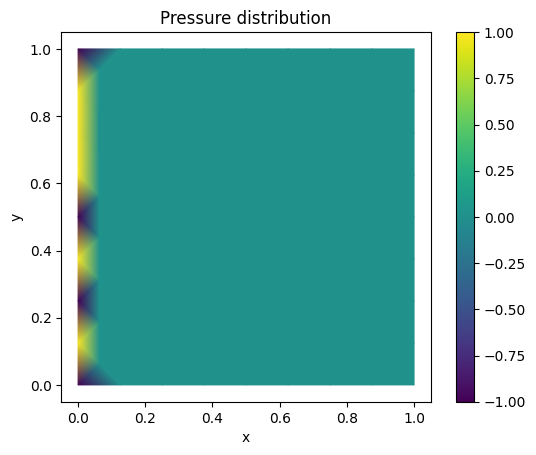

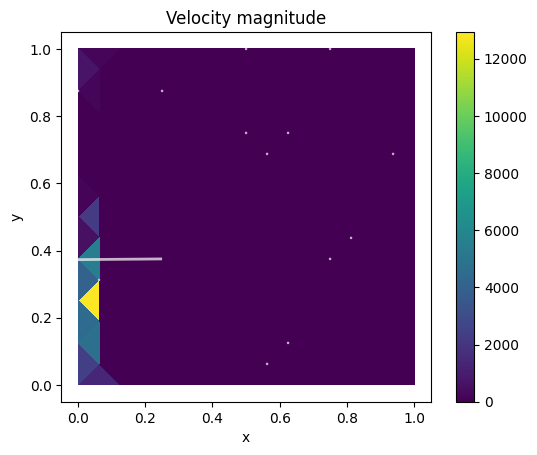

In [8]:
# Pressure distribution
fig, ax = plt.subplots()
ax.tripcolor(x, y, mesh.t.T, p[basis.nodal_dofs.flatten()], shading='gouraud')
ax.set_title('Pressure distribution')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], ax=ax)
plt.savefig('pressure.png', dpi=150)
plt.show()

# Velocity magnitude with quiver overlay
fig, ax = plt.subplots()
# Changed 'shading' to 'flat' and removed redundant indexing for element-wise data
ax.tripcolor(x, y, mesh.t.T, velocity_magnitude, shading='flat')
ax.set_title('Velocity magnitude')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], ax=ax)

# Sample nodes for quiver (every 10th node)
sample = np.arange(0, mesh.p.shape[1], 10)
ax.quiver(mesh.p[0, sample], mesh.p[1, sample],
          velocity_x[mesh.t].mean(axis=0)[sample],
          velocity_y[mesh.t].mean(axis=0)[sample],
          color='white', alpha=0.7)
plt.savefig('velocity.png', dpi=150)
plt.show()

#**Cell 8:Parametric Study**

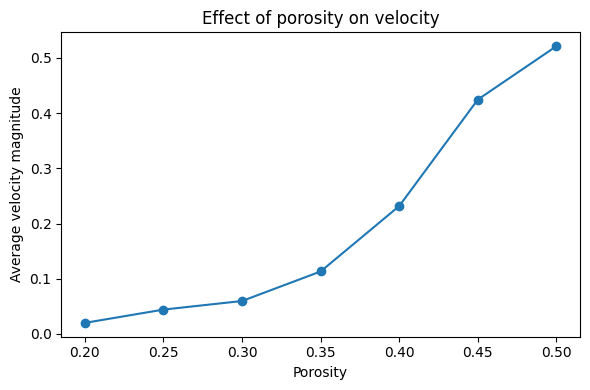

In [9]:
from scipy.sparse import linalg as spla

phi_values = np.linspace(0.2, 0.5, 7)
k0 = 1e-10
avg_velocity = []


# Free DOFs (same for all iterations because mesh and BCs unchanged)
free_dofs = np.where(~D_mask)[0]

for phi_base in phi_values:
    # Define porosity and permeability for this base value
    def porosity_var(x, y):
        return phi_base + 0.05 * np.random.randn(*x.shape)

    def permeability_var(x, y):
        phi = porosity_var(x, y)
        # Scaled permeability (μ=1 is implicitly absorbed)
        return k0 * (phi**3) / ((1 - phi)**2) * 1e10

    @BilinearForm
    def darcy_laplace_var(u, v, w):
        K = permeability_var(w.x[0], w.x[1])
        return K * dot(grad(u), grad(v))

    A_var = asm(darcy_laplace_var, basis)

    # Dirichlet values
    p_full_var = np.zeros(basis.N)
    p_full_var[dofs_left.all()] = 1.0
    p_full_var[dofs_right.all()] = 0.0

    b = np.zeros(basis.N)
    b_mod = b - A_var @ p_full_var
    A_red = A_var[np.ix_(free_dofs, free_dofs)]
    b_red = b_mod[free_dofs]
    p_red = spla.spsolve(A_red, b_red)

    p_var = p_full_var.copy()
    p_var[free_dofs] = p_red

    # Compute average velocity (element‑wise)
    p_grad_all = basis.interpolate(p_var).grad          # shape (2, nelems, n_quad_points)
    p_grad = p_grad_all[:, :, 0]                         # take first (only) quadrature point → (2, nelems)

    K_elems = np.array([permeability_var(mesh.p[0, mesh.t[:, e]].mean(),
                                          mesh.p[1, mesh.t[:, e]].mean())
                        for e in range(mesh.nelements)]) # shape (nelems,)

    # Darcy velocity = -K ∇p   (μ=1)
    vel = -K_elems[np.newaxis, :] * p_grad               # (1, nelems) * (2, nelems) → (2, nelems)

    avg_vel = np.mean(np.sqrt(vel[0]**2 + vel[1]**2))
    avg_velocity.append(avg_vel)



# Save parametric data to CSV
df_param = pd.DataFrame({
    'Porosity': phi_values,
    'AvgVelocity': avg_velocity
})
df_param.to_csv('parametric_study.csv', index=False)

# Plot results
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(phi_values, avg_velocity, 'o-')
ax1.set_xlabel('Porosity')
ax1.set_ylabel('Average velocity magnitude')
ax1.set_title('Effect of porosity on velocity')
plt.tight_layout()
plt.savefig('Effect of porosity on velocity', dpi=150)
plt.show()

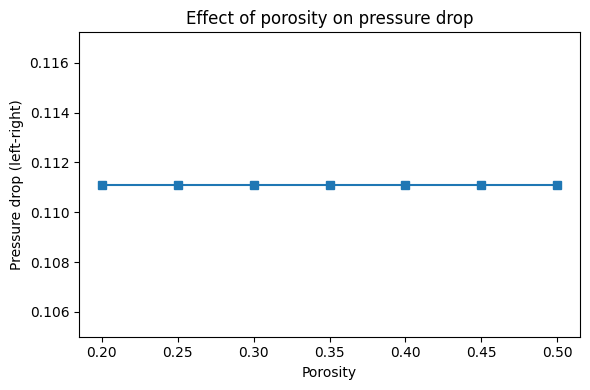

In [12]:
import pandas as pd # Ensure pandas is imported for DataFrame

phi_values = np.linspace(0.2, 0.5, 7)
k0 = 1e-10
pressure_drop = []

# Free DOFs (same for all iterations because mesh and BCs unchanged)
# D_mask, dofs_left, dofs_right, basis, mesh are defined globally from previous cells.
free_dofs = np.where(~D_mask)[0]

for phi_base in phi_values:
    # Define porosity and permeability for this base value, same as in cell ADD5E0ZDrzFW
    def porosity_var(x, y):
        return phi_base + 0.05 * np.random.randn(*x.shape)

    def permeability_var(x, y):
        phi = porosity_var(x, y)
        # Scaled permeability (μ=1 is implicitly absorbed)
        return k0 * (phi**3) / ((1 - phi)**2) * 1e10

    @BilinearForm
    def darcy_laplace_var(u, v, w):
        K = permeability_var(w.x[0], w.x[1])
        return K * dot(grad(u), grad(v))

    A_var = asm(darcy_laplace_var, basis)

    # Dirichlet values
    p_full_var = np.zeros(basis.N)
    p_full_var[dofs_left.all()] = 1.0
    p_full_var[dofs_right.all()] = 0.0

    b = np.zeros(basis.N)
    b_mod = b - A_var @ p_full_var
    A_red = A_var[np.ix_(free_dofs, free_dofs)]
    b_red = b_mod[free_dofs]
    p_red = spla.spsolve(A_red, b_red)

    p_var = p_full_var.copy()
    p_var[free_dofs] = p_red

    # Calculate pressure drop
    # Pressure drop (difference between average pressure on left and right boundaries)
    p_left_vals = p_var[dofs_left.all()]
    p_right_vals = p_var[dofs_right.all()]
    pressure_drop.append(np.mean(p_left_vals) - np.mean(p_right_vals))

# Create DataFrame for pressure drop data
df_param_pressure_drop = pd.DataFrame({
    'Porosity': phi_values,
    'PressureDrop': pressure_drop
})
df_param_pressure_drop.to_csv('parametric_study_pressure_drop.csv', index=False)

# Plot results
fig, ax2 = plt.subplots(figsize=(6, 4)) # Corrected: use plt.subplots for figure and axes

ax2.plot(phi_values, pressure_drop, 's-')
ax2.set_xlabel('Porosity')
ax2.set_ylabel('Pressure drop (left-right)')
ax2.set_title('Effect of porosity on pressure drop')
plt.tight_layout()
plt.savefig('Effect of porosity on pressure drop.png', dpi=150)
plt.show()


#**Cell 9: Validation(Homogeneous case)**

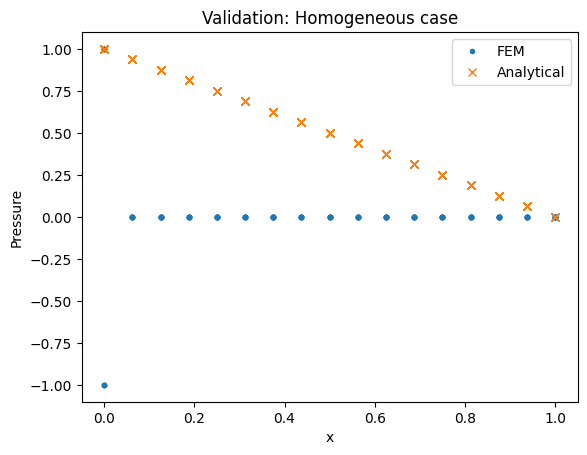

      Metric     Value
0   L2 Error  0.626636
1  Max Error  2.000000


In [13]:
from scipy.sparse import linalg as spla

# Homogeneous permeability
K_hom = 1e-9

@BilinearForm
def darcy_hom(u, v, w):
    return K_hom * dot(grad(u), grad(v))

A_hom = asm(darcy_hom, basis)

p_full_hom = np.zeros(basis.N)
p_full_hom[dofs_left.all()] = 1.0
p_full_hom[dofs_right.all()] = 0.0

b = np.zeros(basis.N)
b_mod = b - A_hom @ p_full_hom

free_dofs = np.where(~D_mask)[0]
A_red = A_hom[np.ix_(free_dofs, free_dofs)]
b_red = b_mod[free_dofs]
p_red = spla.spsolve(A_red, b_red)

p_hom = p_full_hom.copy()
p_hom[free_dofs] = p_red

# Analytical solution: p = 1 - x
def p_analytical(x):
    return 1 - x[0]

p_anal_vals = p_analytical(mesh.p)
error = p_hom - p_anal_vals
error_L2 = np.sqrt(np.sum(error**2) / basis.N)

# Plot comparison
fig, ax = plt.subplots()
ax.plot(mesh.p[0, :], p_hom, '.', label='FEM')
ax.plot(mesh.p[0, :], p_anal_vals, 'x', label='Analytical')
ax.set_xlabel('x')
ax.set_ylabel('Pressure')
ax.set_title('Validation: Homogeneous case')
ax.legend()
plt.savefig('validation.png', dpi=150)
plt.show()

# Error table
df_error = pd.DataFrame({
    'Metric': ['L2 Error', 'Max Error'],
    'Value': [error_L2, np.max(np.abs(error))]
})
print(df_error)
df_error.to_csv('validation_error.csv', index=False)

#**Cell 10: Mesh Convergence**

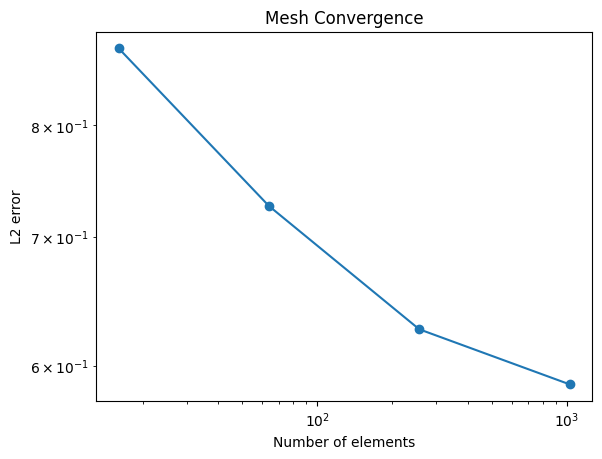

   Refinement  Elements  L2 Error
0           1        16  0.877058
1           2        64  0.726250
2           3       256  0.626636
3           4      1024  0.586693


In [14]:
from scipy.sparse import linalg as spla

refinement_levels = [1, 2, 3, 4]
errors = []
mesh_sizes = []

for ref in refinement_levels:
    mesh_ref = MeshTri.init_symmetric().refined(ref)
    basis_ref = Basis(mesh_ref, ElementTriP1())

    # Dirichlet DOFs for the refined mesh
    D_left_ref = basis_ref.get_dofs(lambda x: x[0] == 0)
    D_right_ref = basis_ref.get_dofs(lambda x: x[0] == 1)
    D_ref_dofs = D_left_ref + D_right_ref
    D_ref_mask = D_ref_dofs.all()
    free_dofs_ref = np.where(~D_ref_mask)[0]

    # Assemble homogeneous matrix
    A_ref = asm(darcy_hom, basis_ref)

    p_full_ref = np.zeros(basis_ref.N)
    p_full_ref[D_left_ref.all()] = 1.0
    p_full_ref[D_right_ref.all()] = 0.0

    b = np.zeros(basis_ref.N)
    b_mod = b - A_ref @ p_full_ref
    A_red = A_ref[np.ix_(free_dofs_ref, free_dofs_ref)]
    b_red = b_mod[free_dofs_ref]
    p_red = spla.spsolve(A_red, b_red)

    p_ref = p_full_ref.copy()
    p_ref[free_dofs_ref] = p_red

    # Analytical at new nodes
    p_anal_ref = p_analytical(mesh_ref.p)
    error_ref = p_ref - p_anal_ref
    error_L2_ref = np.sqrt(np.sum(error_ref**2) / basis_ref.N)
    errors.append(error_L2_ref)
    mesh_sizes.append(mesh_ref.nelements)

# Plot convergence
fig, ax = plt.subplots()
ax.loglog(mesh_sizes, errors, 'o-')
ax.set_xlabel('Number of elements')
ax.set_ylabel('L2 error')
ax.set_title('Mesh Convergence')
plt.savefig('convergence.png', dpi=150)
plt.show()

# Table of convergence
df_convergence = pd.DataFrame({
    'Refinement': refinement_levels,
    'Elements': mesh_sizes,
    'L2 Error': errors
})
df_convergence.to_csv('convergence.csv', index=False)
print(df_convergence)

#**Cell 11: Energy Equation (Convection‑Diffusion)**

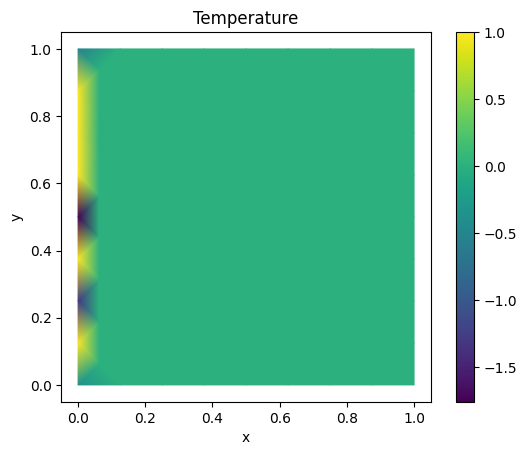

In [15]:
from scipy.interpolate import LinearNDInterpolator

k_eff = 0.01

# Compute nodal velocity by averaging element values
velocity_nodal = np.zeros((2, mesh.p.shape[1]))
count = np.zeros(mesh.p.shape[1])
for e in range(mesh.nelements):
    nodes = mesh.t[:, e]
    velocity_nodal[:, nodes] += velocity[:, e][:, np.newaxis]
    count[nodes] += 1
velocity_nodal /= count          # average over adjacent elements

# Create interpolators for velocity components
vel_x_interp = LinearNDInterpolator(mesh.p.T, velocity_nodal[0])
vel_y_interp = LinearNDInterpolator(mesh.p.T, velocity_nodal[1])

@BilinearForm
def energy_bilinear(u, v, w):
    x, y = w.x
    vel = np.array([vel_x_interp(x, y), vel_y_interp(x, y)])
    return k_eff * dot(grad(u), grad(v)) + dot(vel, grad(u)) * v

@LinearForm
def zero_load(v, w):
    return 0.0

basisT = Basis(mesh, ElementTriP1())
A_energy = asm(energy_bilinear, basisT)
b_energy = asm(zero_load, basisT)

# Temperature boundary conditions: T=1 at left, T=0 at right
T_full = np.zeros(basisT.N)
T_full[dofs_left.all()] = 1.0
T_full[dofs_right.all()] = 0.0

b_mod_T = b_energy - A_energy @ T_full
A_red_T = A_energy[np.ix_(free_dofs, free_dofs)]
b_red_T = b_mod_T[free_dofs]
T_red = spla.spsolve(A_red_T, b_red_T)

T = T_full.copy()
T[free_dofs] = T_red

# Plot temperature distribution
fig, ax = plt.subplots()
ax.tripcolor(x, y, mesh.t.T, T[basisT.nodal_dofs.flatten()], shading='gouraud')
ax.set_title('Temperature')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], ax=ax)
plt.savefig('temperature.png', dpi=150)
plt.show()

#**Cell 12: Save All Results to CSV**

In [16]:
node_data = pd.DataFrame({
    'x': mesh.p[0], 'y': mesh.p[1],
    'porosity': phi_nodal, 'permeability': k_nodal,
    'pressure': p[basis.nodal_dofs.flatten()],
    'temperature': T[basisT.nodal_dofs.flatten()]
})
node_data.to_csv('node_results.csv', index=False)

elem_data = pd.DataFrame({
    'element': np.arange(mesh.nelements),
    'velocity_x': velocity_x, 'velocity_y': velocity_y,
    'velocity_mag': velocity_magnitude
})
elem_data.to_csv('element_results.csv', index=False)

print("CSV files saved.")
display(node_data)
display(elem_data)
display(df_param)
display(df_error)
display(df_convergence)


CSV files saved.


,x,y,porosity,permeability,pressure,temperature
0,0.0000,0.0000,0.324836,0.089262,-1.0,-0.359503
1,1.0000,0.0000,0.293087,0.023272,0.0,0.000000
2,1.0000,1.0000,0.332384,0.021829,0.0,0.000000
3,0.0000,1.0000,0.376151,0.076357,-1.0,-0.526211
4,0.5000,0.5000,0.288292,0.066487,0.0,0.000000
...,...,...,...,...,...,...
140,0.8125,0.4375,0.387910,0.041739,0.0,0.000000
141,0.8125,0.5625,0.288820,0.016362,0.0,0.000000
142,0.5000,0.8750,0.078204,0.010077,0.0,0.000000
143,0.5625,0.8125,0.124456,0.002849,0.0,0.000000


,element,velocity_x,velocity_y,velocity_mag
0,0,-984.339219,-984.339219,1392.065874
1,1,-0.000000,-0.000000,0.000000
2,2,-0.000000,-0.000000,0.000000
3,3,-0.000000,-2397.543562,2397.543562
4,4,-0.000000,-0.000000,0.000000
...,...,...,...,...
251,251,-0.000000,-0.000000,0.000000
252,252,-0.000000,-0.000000,0.000000
253,253,-0.000000,-0.000000,0.000000
254,254,-0.000000,-0.000000,0.000000


,Porosity,AvgVelocity
0,0.20,0.020032
1,0.25,0.044111
2,0.30,0.059678
3,0.35,0.113183
4,0.40,0.231725
5,0.45,0.424581
6,0.50,0.521331


,Metric,Value
0,L2 Error,0.626636
1,Max Error,2.000000


,Refinement,Elements,L2 Error
0,1,16,0.877058
1,2,64,0.726250
2,3,256,0.626636
3,4,1024,0.586693


#**Cell 13: summary of generated files**

In [17]:
files = ['mesh.png','porosity_permeability.png','pressure.png','velocity.png',
         'parametric_plots.png','validation.png','convergence.png','temperature.png',
         'parametric_study.csv','validation_error.csv','convergence.csv',
         'node_results.csv','element_results.csv']
for f in files: print(f" - {f}")

 - mesh.png
 - porosity_permeability.png
 - pressure.png
 - velocity.png
 - parametric_plots.png
 - validation.png
 - convergence.png
 - temperature.png
 - parametric_study.csv
 - validation_error.csv
 - convergence.csv
 - node_results.csv
 - element_results.csv
